<a href="https://colab.research.google.com/github/navyasripenmetsa/CSL2050_PRML_Major_Course_Project/blob/Logistic_Regresion/logistic_regression_colour_histogram_poly_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Degree: 1
Accuracy: 0.9348
Precision: 0.9400
Recall: 0.9348
F1 Score: 0.9327

Degree: 2
Accuracy: 0.9545
Precision: 0.9591
Recall: 0.9545
F1 Score: 0.9528

Degree: 3
Accuracy: 0.9510
Precision: 0.9572
Recall: 0.9510
F1 Score: 0.9495


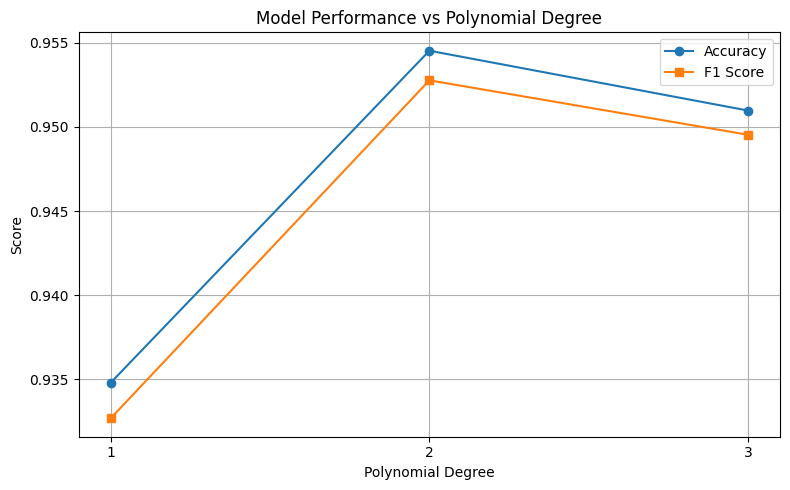

In [2]:
import pandas as pd                                      # importing pandas to handle dataset reading
from sklearn.linear_model import LogisticRegression      # importing logistic regression model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # importing evaluation metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures   # importing preprocessing tools
import matplotlib.pyplot as plt                          # importing matplotlib for plotting graphs

# Load datasets
train_df = pd.read_csv('/content/colour_Histogram_Training.csv')     # loading training dataset
test_df = pd.read_csv('/content/colour_Histogram_Testing.csv')       # loading testing dataset

# Prepare feature matrix and target variable
X_train = train_df.drop(columns=['filename', 'class'])   # selecting features from training set
y_train = train_df['class']                              # selecting labels from training set
X_test = test_df.drop(columns=['filename', 'class'])     # selecting features from testing set
y_test = test_df['class']                                # selecting labels from testing set

# Encode class labels into numeric values
label_encoder = LabelEncoder()                         # initializing label encoder
y_train_encoded = label_encoder.fit_transform(y_train) # encoding training labels
y_test_encoded = label_encoder.transform(y_test)       # encoding testing labels using same encoder

# Standardize features to zero mean and unit variance
scaler = StandardScaler()                        # creating standard scaler object
X_train_scaled = scaler.fit_transform(X_train)   # fitting and transforming training features
X_test_scaled = scaler.transform(X_test)         # transforming testing features using the same scaler

# Initialize lists to store results
degrees = [1, 2, 3]                 # degrees of polynomial features to compare
accuracies = []                    # to store accuracy values
f1_scores = []                     # to store F1 scores

# Loop over different polynomial degrees
for degree in degrees:
    poly = PolynomialFeatures(degree=degree, interaction_only=True)  # creating polynomial features with interactions
    X_train_poly = poly.fit_transform(X_train_scaled)                # fitting and transforming training data
    X_test_poly = poly.transform(X_test_scaled)                      # transforming test data using same polynomial basis

    model = LogisticRegression(max_iter=1000)              # creating logistic regression model
    model.fit(X_train_poly, y_train_encoded)               # training the model
    y_pred = model.predict(X_test_poly)                    # predicting on test data

    acc = accuracy_score(y_test_encoded, y_pred)           # calculating accuracy
    f1 = f1_score(y_test_encoded, y_pred, average='weighted')    # calculating weighted F1 score
    prec = precision_score(y_test_encoded, y_pred, average='weighted')  # calculating weighted precision
    rec = recall_score(y_test_encoded, y_pred, average='weighted')      # calculating weighted recall

    # Display metrics for current degree
    print(f"\nDegree: {degree}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")

    accuracies.append(acc)         # saving accuracy value
    f1_scores.append(f1)           # saving F1 score

# Plot Accuracy and F1 Score vs Degree
plt.figure(figsize=(8, 5))                       # setting the size of the graph
plt.plot(degrees, accuracies, marker='o', label='Accuracy')   # plotting accuracy values
plt.plot(degrees, f1_scores, marker='s', label='F1 Score')     # plotting F1 score values
plt.title('Model Performance vs Polynomial Degree')            # setting graph title
plt.xlabel('Polynomial Degree')                                # labeling x-axis
plt.ylabel('Score')                                            # labeling y-axis
plt.grid(True)                                                 # enabling grid
plt.legend()                                                   # showing legend
plt.xticks(degrees)                                            # setting x-axis ticks
plt.tight_layout()                                             # adjusting layout
plt.show()                                                     # displaying the plot
